In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

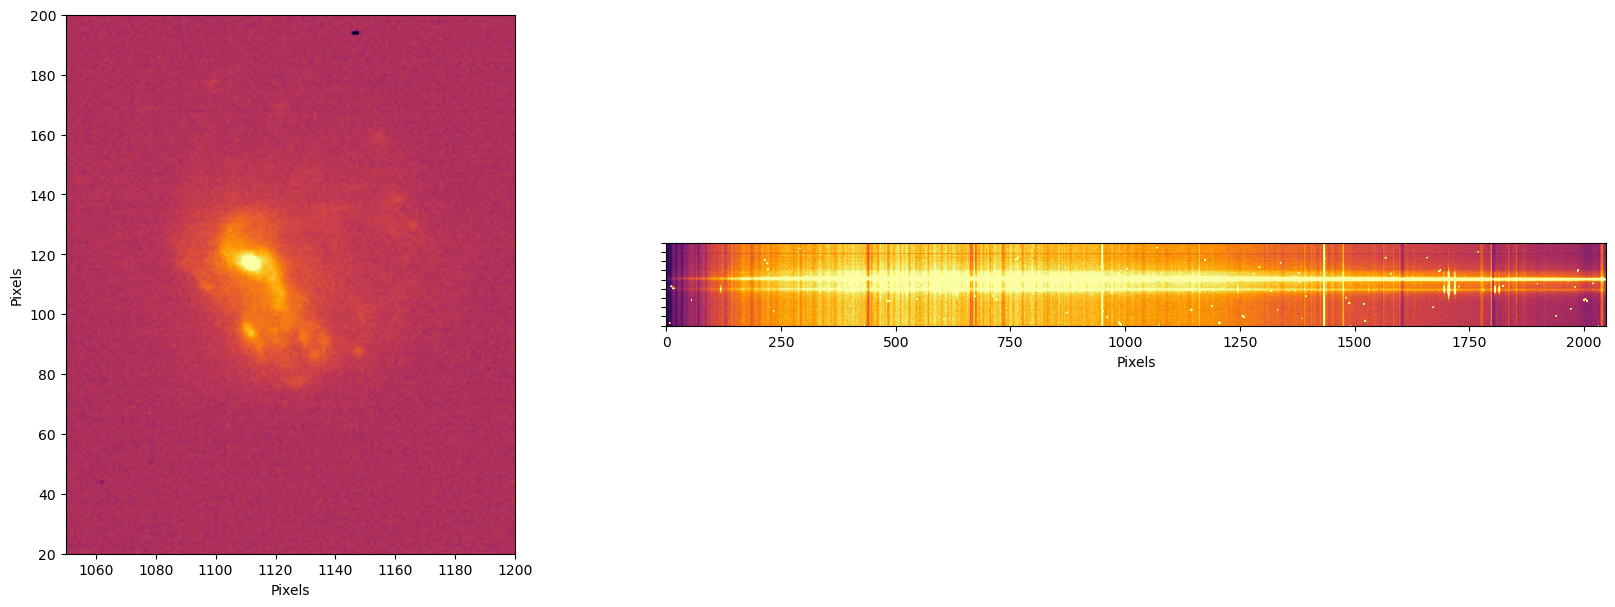

In [2]:
# Open the FITS file
hdul = fits.open("FORS2.2021-08-21T05_42_53.877.fits") #spectrum
hdul2 = fits.open("FORS2.2021-08-21T05_29_16.174.fits") #image
# Display info about the file structure
#hdul.info()

# Access the data - typically in the first or primary HDU
# (Header Data Unit)
image_data = hdul[0].data
image_data2 = hdul2[0].data

# View the header information which contains metadata
#header = hdul[0].header
#print(header)

fig, ax = plt.subplots(1,2, gridspec_kw={'width_ratios': [1,2]}, figsize=(20, 7), sharey=True)

im1 = ax[0].imshow(np.log10(image_data2), cmap='inferno', vmin=np.log10(2000), vmax=np.log10(6000))
ax[0].set_ylim(20, 200)
ax[0].set_xlim(1050, 1200)
ax[0].set_xlabel('Pixels')
ax[0].set_ylabel('Pixels')

im2 = ax[1].imshow(image_data, cmap='inferno', vmin=np.percentile(image_data, 5), vmax=np.percentile(image_data, 95))
ax[1].set_ylim(20, 200)
#ax[1].set_xlim(500, 1170)
ax[1].set_xlabel('Pixels')
#ax[1].set_ylabel('Pixels')

# Don't forget to close the file when done
hdul.close()
hdul2.close()

In [3]:
image_cut = image_data[55:155]
image_cut_2 = image_data2[60:160, 1050:1200]

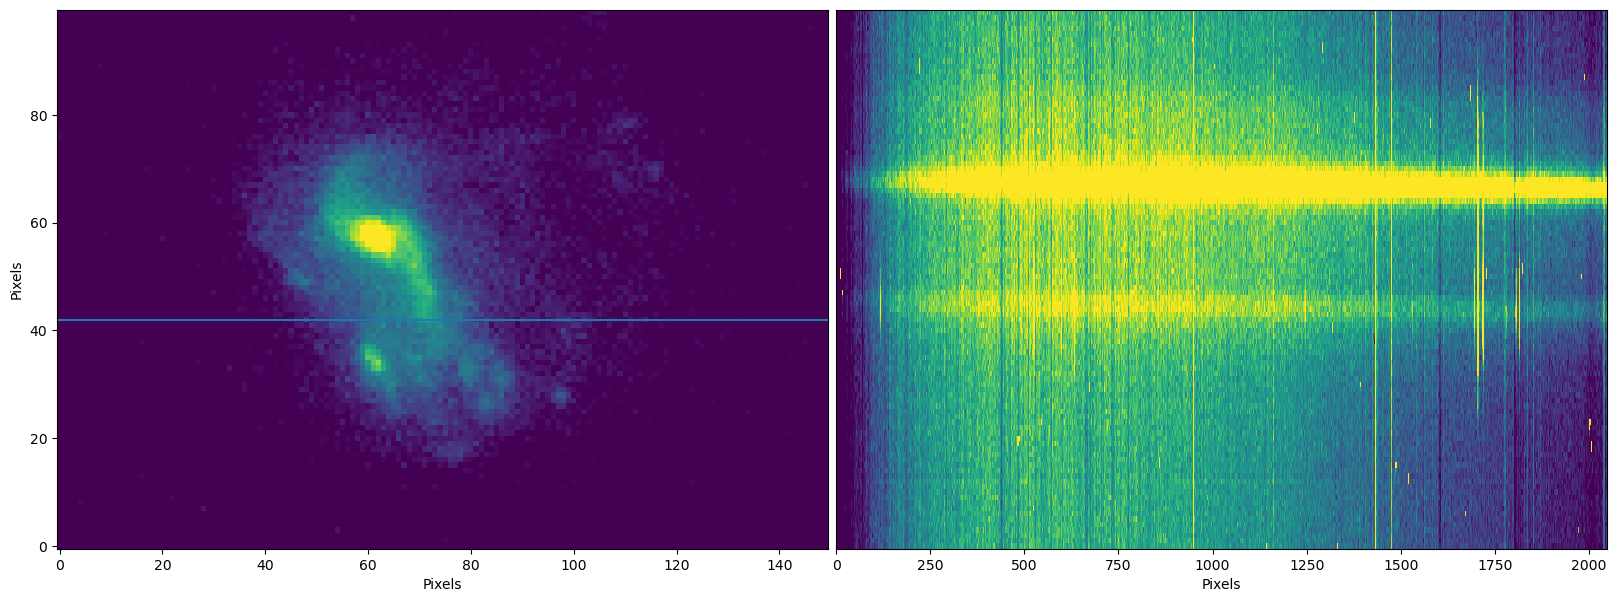

In [7]:
J, N = image_cut.shape
x = np.arange(0, N, 1)
y = np.arange(0, J, 1)

x_grid, y_grid = np.meshgrid(x, y)

J_2, N_2 = image_cut_2.shape
x_2 = np.arange(0, N_2, 1)
y_2 = np.arange(0, J_2, 1)

x_grid_2, y_grid_2 = np.meshgrid(x_2, y_2)

fig, ax = plt.subplots(1,2, figsize=(20, 7), sharey=True)
ax[1].pcolormesh(x_grid, y_grid, image_cut, shading='nearest', vmin=np.percentile(image_data, 10), vmax=np.percentile(image_data, 99), cmap = 'viridis') #altre opzioni
ax[0].pcolormesh(x_grid_2, y_grid_2, np.log10(image_cut_2), shading='nearest', vmin=np.log10(3500), vmax=np.log10(5800), cmap = 'viridis') #hot: 2500, 6000
ax[0].set_xlabel('Pixels')
ax[1].set_xlabel('Pixels')
ax[0].set_ylabel('Pixels')
ax[1].tick_params(axis='y', which='both', left=False, right=False)
ax[0].axhline(42)

plt.subplots_adjust(wspace=0.01)

In [8]:
N

2048

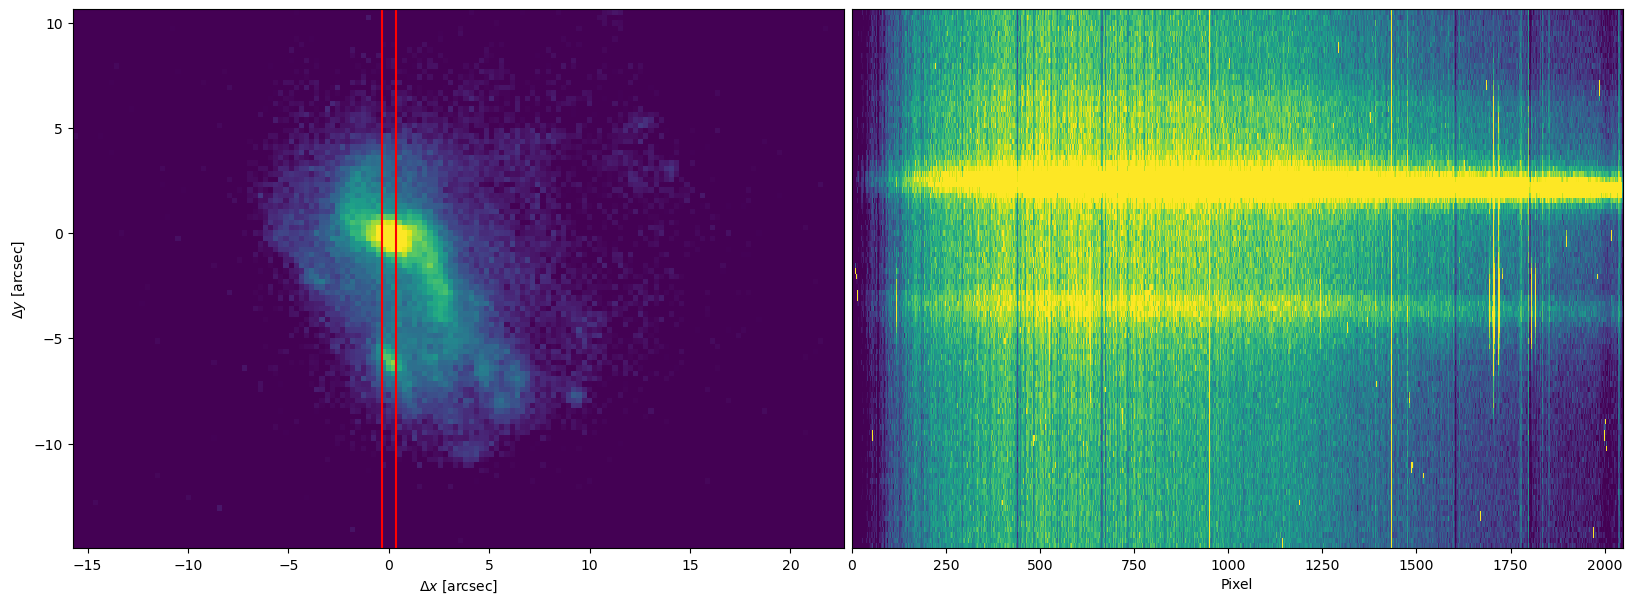

In [5]:
arcsec_x = np.arange(-61*0.256, 89*0.256, 0.256)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

J, N = image_cut.shape
x = np.arange(0, N, 1)

x_grid, y_grid = np.meshgrid(x, arcsec_y)

x_grid_2, y_grid_2 = np.meshgrid(arcsec_x, arcsec_y)

fig, ax = plt.subplots(1,2, figsize=(20, 7), sharey=True)

ax[0].pcolormesh(x_grid_2, y_grid_2, np.log10(image_cut_2), shading='nearest', vmin=np.log10(3500), vmax=np.log10(5800), cmap = 'viridis') #hot: 2500, 6000
ax[0].set_xlabel(r'$\Delta x$ [arcsec]')
ax[0].set_ylabel(r'$\Delta y$ [arcsec]')
ax[0].axvline(-0.35, color='red')
ax[0].axvline(0.35, color='red')

ax[1].pcolormesh(x_grid, y_grid, image_cut, shading='nearest', vmin=np.percentile(image_data, 10), vmax=np.percentile(image_data, 99), cmap = 'viridis') #altre opzioni
ax[1].set_xlabel('Pixel')
ax[1].tick_params(axis='y', which='both', left=False, right=False)

plt.subplots_adjust(wspace=0.01)
#fig.savefig("Galaxy_not_reduced_spectrum.png")

In [6]:
hdul = fits.open("FORS2.2021-08-21T05_29_16.174.fits") #image
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits") #spectrum
image_data = hdul[0].data
image_data_2 = hdul2[0].data

In [16]:
image_cut = image_data[60:160, 1046:1176]
image_cut_2 = image_data_2[60:160, 0:1800]

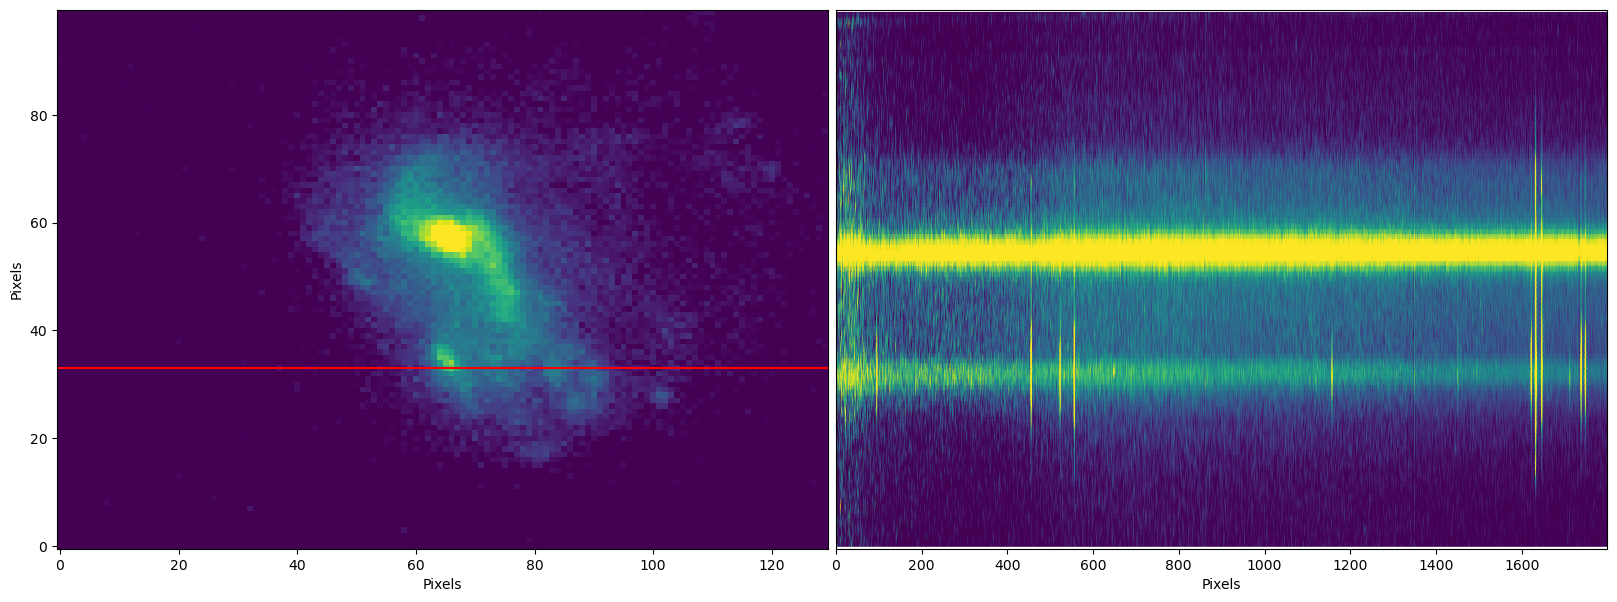

In [17]:
J, N = image_cut.shape
x = np.arange(0, N, 1)
y = np.arange(0, J, 1)

x_grid, y_grid = np.meshgrid(x, y)

J_2, N_2 = image_cut_2.shape
x_2 = np.arange(0, N_2, 1)
y_2 = np.arange(0, J_2, 1)

x_grid_2, y_grid_2 = np.meshgrid(x_2, y_2)

fig, ax = plt.subplots(1,2, figsize=(20, 7), sharey=True)
ax[1].pcolormesh(x_grid_2, y_grid_2, image_cut_2, shading='gouraud', vmin=np.percentile(image_cut_2, 20), vmax=np.percentile(image_cut_2, 95), cmap = 'viridis') #altre opzioni
ax[0].pcolormesh(x_grid, y_grid, np.log10(image_cut), shading='nearest', vmin=np.log10(3500), vmax=np.log10(5800), cmap = 'viridis')
ax[0].set_xlabel('Pixels')
ax[1].set_xlabel('Pixels')
ax[0].set_ylabel('Pixels')
ax[1].tick_params(axis='y', which='both', left=False, right=False)
ax[0].axhline(33, color ='red')

plt.subplots_adjust(wspace=0.01)

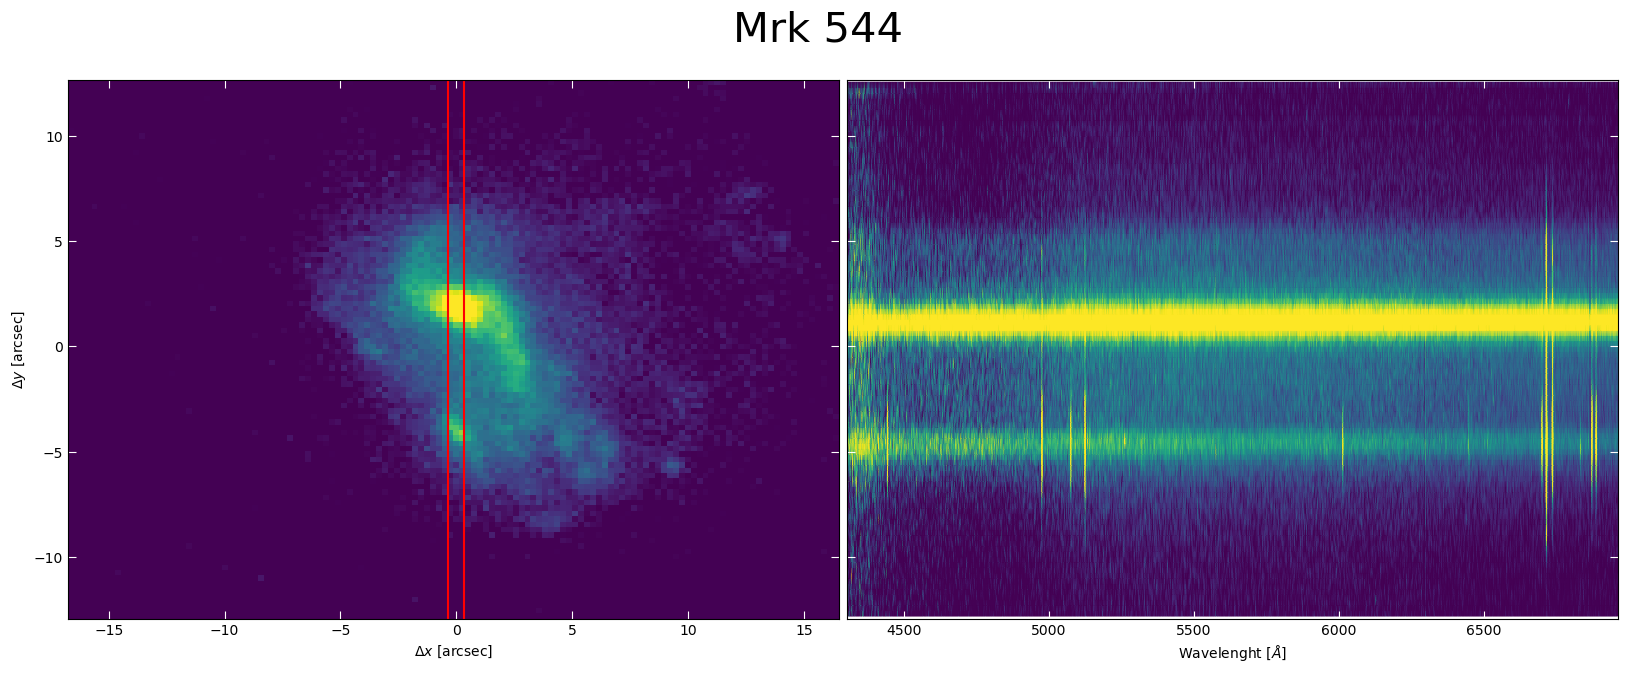

In [19]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
arcsec_x = np.arange(-65*0.256, 65*0.256, 0.256)
arcsec_y = np.arange(-50*0.256, 50*0.256, 0.256)

x_grid, y_grid = np.meshgrid(arcsec_x, arcsec_y)

x_grid_2, y_grid_2 = np.meshgrid(wavelenghts, arcsec_y)

fig, ax = plt.subplots(1,2, figsize=(20, 7), sharey=True)
fig.suptitle('Mrk 544', fontsize=30)

ax[0].pcolormesh(x_grid, y_grid, np.log10(image_cut), shading='nearest',  vmin=np.log10(3500), vmax=np.log10(5800), cmap = 'viridis')
ax[0].set_xlabel(r'$\Delta x$ [arcsec]')
ax[0].set_ylabel(r'$\Delta y$ [arcsec]')
ax[0].axvline(-0.35, color='red')
ax[0].axvline(0.35, color='red')
ax[0].tick_params(axis='both', which='both', direction='in', color = 'white', top=True, bottom=True, left=True, right=True, length = 6)

ax[1].pcolormesh(x_grid_2, y_grid_2, image_cut_2, shading='gouraud', vmin=np.percentile(image_cut_2, 20), vmax=np.percentile(image_cut_2, 95)) #altre opzioni
ax[1].set_xlabel(r'Wavelenght [$\AA$]')
ax[1].tick_params(axis='both', which='both', direction='in', color = 'white', top=True, bottom=True, left=True, right=True, length = 6)

plt.subplots_adjust(wspace=0.01)
fig.savefig("Galaxy_reduced_spectrum_Mrk544.png")